# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3

### **Rotación de Personal - IBM**

#### **Nombre y matrícula: Fernando Gomez Moreno - A00354097**

------------

* #### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance".**

* #### **Los datos los proporcionó IBM y aunque comentaron que por cuestiones de privacidad los datos son sintéticos, los generaron con base a su experiencia. Estos datos en general son referencia cuando se habla en Estadística o Aprendizaje Automático sobre el tema de rotación de personal.**

**El archivo contiene 1470 registros:**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: ++++++++++++
La rotación de personal en las organizaciones es un problema y se refiere al fenómeno por el cual los empleados abandonan una organización por diferentes motivos. Puede ser voluntaria (renuncias) o involutaria (despidos y jubilaciones).
Para la organización es un problema porque:
1 - La salida de un empleado de una empresa implica costos significativos asociados al reclutamiento, selección y capacitación de un reemplazo.
2 - Se pierde conocimiento. El empleado se lleva experiencia, conocimientos técnicos que son dificiles de cubrir en corto plazo.
3 - Impacta positivamente en la moral. La rotación puede afectar negativamente el clima organizacional y la productividad de los equipos que permanecen en la empresa.
4 - Afecta en la continuidad del negocio. La inestabilidad en puestos clave puede retrasar proyectos, entregas y fechas claves afectando la calidad del servicio o producto.
++++++++ Termina la sección de agregar texto. +++++++++++

In [250]:
# Agrega aquí todas las librerías adicionales o paquetes que consideres necesarias:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import OrdinalEncoder

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report



* #### **Descarga el archivo de datos de la página de Kaggle.**

* #### **Cargamos el archivo como un DataFrame de Pandas y hacemos uso del método “describe” con el argumento include= “all” para desplegar información de todas las variables, numéricas y categóricas.**

In [251]:
#path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
path = "/Users/chicano/Documents/Tec/2-Trimestre/Inteligencia artificial y aprendizaje automático/3 semana/WA_Fn-UseC_-HR-Employee-Attrition.csv"
data = pd.read_csv(path)

print("Tamaño del DataFrame:", data.shape)
data.describe(include = 'all').T


Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 2:**

**a)  Realiza los análisis descriptivos y/o gráficos que creas adecuados, para identificar 4 factores que se deben eliminar desde un inicio.**

**b) Con base a tu análisis anterior, indica cuáles son estas 4 variables y la justificación de por qué se pueden eliminar.**

**c) Al nuevo DataFrame sin las variables indicadas, llamarlo df.**



In [252]:
# a) Incluye a continuación el código y celdas que creas adecuados para responder a la pregunta.
# 1 - Variables de varianza 0. Son aquellas que teien el mismo valor para todos los registros.
# 2 - Variables de identificación. Son aquellas que funcionan como un ID único y no representan un patrón de comportamiento.
# Basado en el análisis anterior, las 4 varaibles a eliminar son:
# - EmployeeCount -> Tiene el valor 1 para todos los registros.
# - Over18 -> Contiene el valor Y (si) para todos los registros. Todos los empleados son mayores de edad.
# - StandardHours -> Tiene el valor constante de 80 para todos los empleados.
# - EmployeeNumber -> Valor único para cada empleado. No ayuda a encontrar patrones generales de rotación.
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

# Definimos las columnas a eliminar
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = data.drop(columns=cols_to_drop)

# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++


# Verifiquemos de qué tamaño queda el nuevo DataFrame:
print("Tamaño del nuevo DataFrame:", df.shape)

Tamaño del nuevo DataFrame: (1470, 31)


# **Ejercicio 3:**

#### **Una vez eliminadas las variables no deseadas, clasifiquemos las restantes.**

#### **Realiza los análisis que creas adecuados para clasificar cada una de nuestras variables según su tipo.**

#### **Debes analizar todas las variables de entrada y también la de salida.**


++++++++ Inicia la sección de agregar texto: ++++++++++++

**a)   Variables numéricas:**

   * **Número de variables:** 14
   * **Nombre de las variables:** Age, DailyRate, DistanceFromHome, HourlyRate, MonthlyIncome, MonthlyRate, NumCompaniesWorked, PercentSalaryHike, TotalWorkingYears, TrainingTimesLastYear, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager. (Variables de entrada)

**b)   Variables ordinales:**

   * **Número de variables:** 9
   * **Nombre de las variables:** Education, EnvironmentSatisfaction, JobInvolvement, JobLevel, JobSatisfaction, PerformanceRating, RelationshipSatisfaction, StockOptionLevel, WorkLifeBalance. (Variables de entrada)

##### NOTA: Considera aquí las 7 variables que se indican en la página de Kaggle e incluye también las variables "Level".


**c)   Variables binarias:**

   * **Número de variables:** 3
   * **Nombre de las variables:** Attrition (variable de salida), Gender, OverTime. (Variables de entrada)


**d)   Variables nominales:**

   * **Número de variables:** 5
   * **Nombre de las variables:** BusinessTravel, Department, EducationField, JobRole, MaritalStatus.



++++++++ Termina la sección de agregar texto. +++++++++++


# **Ejercicio 4:**

#### **Como hemos comentado previamente, la forma en que se particiona el conjunto de datos es un aspecto fundamental dentro del área de aprendizaje automático. Ahora que ya también conoces la técnica de Validación Cruzada, explica cómo puede utilizarse cada una de las particiones iniciales indicadas y cuáles son los pros y contras de utilizar cada una de ellas. Se desea comparar la partición inicial de Train+Validation, en contraste con la partición Train+Validation+Test.**



++++++++ Inicia la sección de agregar texto: ++++++++++++

**a) Partición Train+Validation:** Los datos se dividen en dos grupos, uno para entrenar el modelo y el otro para ajustar sus parámetros y validar su precisión.

  * **Pros:** Mayor cantidad de datos para entrenamiento al no tener un tercer grupo como (Test). Es ideal para datasets pequeños cuando hay pocos registros. El flujo de trabajo es más rápido y menos complejo de implementar.
  * **Contras:** Riesgo de sobreajuste en validación. Se usa el set de validación repetidamente para elegir el mejor modelo. La métrica de desempeño final suele ser más alta de lo que realmente será.

**b) Partición Train+Validation+Test:** Se divide el dataset en 3, entrenamiento, validación y test.

  * **Pros:** El conjunto de Test actúa como una "caja negra" que el modelo nunca ha visto ni usado para ajustarse. Da una estimación realista de cómo funcionará el model con nuevos empleados. Previene el filtrado de datos, asegurando que las decisiones tomadas durante el ajuste de hiperparámetros no contaminen la evaluación final.
  * **Contras:** Variablididad. Si el dataset es muy pequeño, la partición de Test podría no ser representativa de toda la población por puro azar. Reducción del conjunto de entrenamiento. Reservar datos para Test y Validación deja menos información disponible para que el modelo aprenda.

  ++++++++ Termina la sección de agregar texto: ++++++++++++

### **Para esta actividad usaremos una partición en Train, Val y Test, con los porcentajes que se indican a continuación.**

In [253]:
print("Dimensiones y Porcentajes de la partición Train+Validation+Test generada:")
print("-"*75)

X = df.drop(columns='Attrition')
y = df[['Attrition']]

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.70, stratify=y, random_state=17)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, stratify=ytv, random_state=17)

print("Variables de entrada Train, Validation, Test:")
print(Xtrain.shape, '%.1f%%' % (100.*Xtrain.shape[0]/X.shape[0]))
print(Xval.shape, '%.1f%%' % (100.*Xval.shape[0]/X.shape[0])),
print(Xtest.shape, '%.1f%%' % (100.*Xtest.shape[0]/X.shape[0]))

print("\nVariables de salida Train, Validation, Test:")
print(ytrain.shape)
print(yval.shape)
print(ytest.shape)

Dimensiones y Porcentajes de la partición Train+Validation+Test generada:
---------------------------------------------------------------------------
Variables de entrada Train, Validation, Test:
(1029, 30) 70.0%
(220, 30) 15.0%
(221, 30) 15.0%

Variables de salida Train, Validation, Test:
(1029, 1)
(220, 1)
(221, 1)


# **Ejercicio 5:**


**a) Aplica la transformación LabelEncoder() de Sklearn a la variable“Attrition”, tomando en cuenta los siguientes puntos:**

* **Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT.**

* **Al aplicar la transformación LabelEncoder deberás evitar el filtrado de información (data-leakage).**


In [254]:
# a)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

# Inicializamos el codificador
le = LabelEncoder()

le.fit(ytrain['Attrition'].values.ravel())

# Transformamos los conjuntos de datos y los guardamos en nuevos DataFrames
ytrainT = pd.DataFrame(le.transform(ytrain['Attrition'].values.ravel()), columns=['Attrition'], index=ytrain.index)
yvalT = pd.DataFrame(le.transform(yval['Attrition'].values.ravel()), columns=['Attrition'], index=yval.index)
ytestT = pd.DataFrame(le.transform(ytest['Attrition'].values.ravel()), columns=['Attrition'], index=ytest.index)

# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


print('Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):\n', ytrainT['Attrition'].value_counts() / ytrainT.shape[0])

Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):
 Attrition
0    0.838678
1    0.161322
Name: count, dtype: float64


#### Además, responde las siguientes preguntas:

**b) Con base a la documentación actual de Sklearn, ¿a qué tipo de variables se recomienda aplicar la transformación LabelEncoder?**

**c) Con base al contexto del problema, ¿qué significan los valores 0 (NO) y 1 (YES) de la variable de salida Attrition?**

**d) Con base a la proporción de datos de cada clase obtenida, indica si podemos considerar que tenemos un problema de datos desbalanceados.**

**e) Con base a esta información, ¿cuál será el umbral del modelo base (baseline) a superar para evitar tener un modelo subentrenado una vez que empecemos a generarlos?**




++++++++ Inicia la sección de agregar texto: ++++++++++++

## **SOLUCIÓN PARA EL PROFESOR:**

b) Según la documentación oficial de Scikit-Learn, LabelEncoder debe utilizarse exclusivamente para codificar la variable de salida (target) y no para las variables de entrada (feature).   

c) 0 o No representa el empleado que permanece en la organización (Negativo a la rotación). 1 o Si representa al empleado que deja la organización (Positivo a la rotación/deserción).  

d) Si, La proporción obtenida en el conjunto de entrenamiento muestra que aproximadamente el 83.9% de los empleados se quedan (0) y solo el 16.1% se van (1). Existe una disparidad significativa entre los que se quedan y se van (la relación es 5 a 1 aproximadamente)

e) El umbral del modelo base es de 83.87% o 0.838

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 6:**


#### **Incluye a continuación un análisis gáfico y descriptivo que consideres adecuado.**

  * **a) El análisis debe ser suficiente para que te ayude a tomar las decisiones sobre qué transformaciones aplicar a cada variable antes de entrenar los modelos.**

  * **b) Además, para obtener mayor información sobre la relación entre variables, incluye un gráfico de barras de frecuencias ordenadas de mayor a menor, de la variable "Age", únicamente para los casos de empleados que ya no están en la compañía (Attrition=Yes).**

  * **c) Incluye también un gráfico de barras ordenado de la relación entre Education y Attrition=Yes. Muestra además en el gráfico las etiquetas asociadas a Education en lugar de los números, como se indica en la página de Kaggle.**

  * **d) [Opcional] Incluye algún otro gráfico o gráficos que consideres aporta información para el análisis y entendimiento del problema. Si no encuentras algún otro gráfico de interés, deberas indicarlo.**

  * **e) Incluye algunos comentarios sobre los resultados y gráficos obtenidos.**


Estadísticas descriptivas de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0


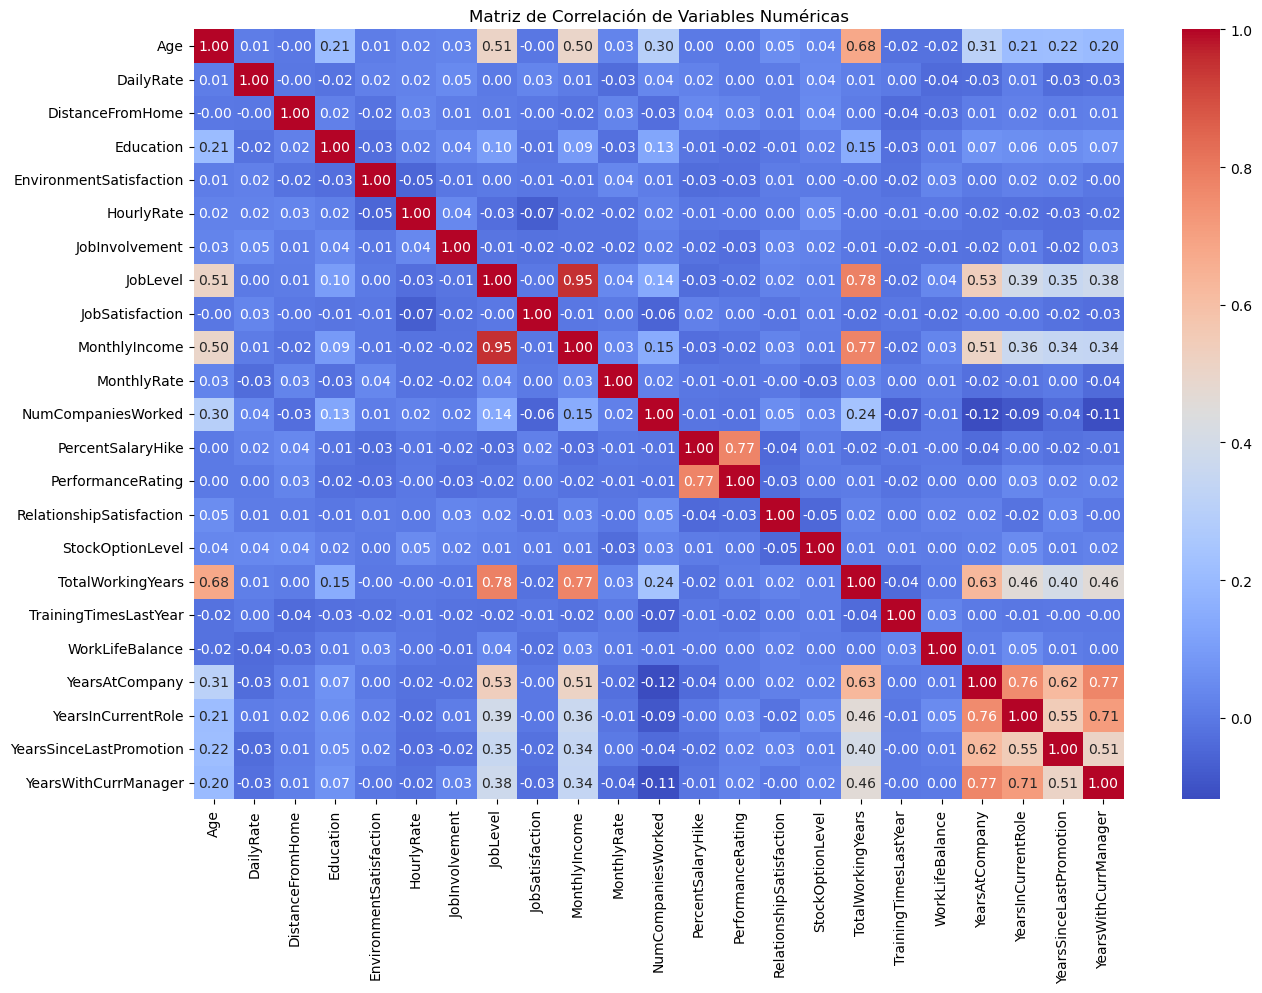

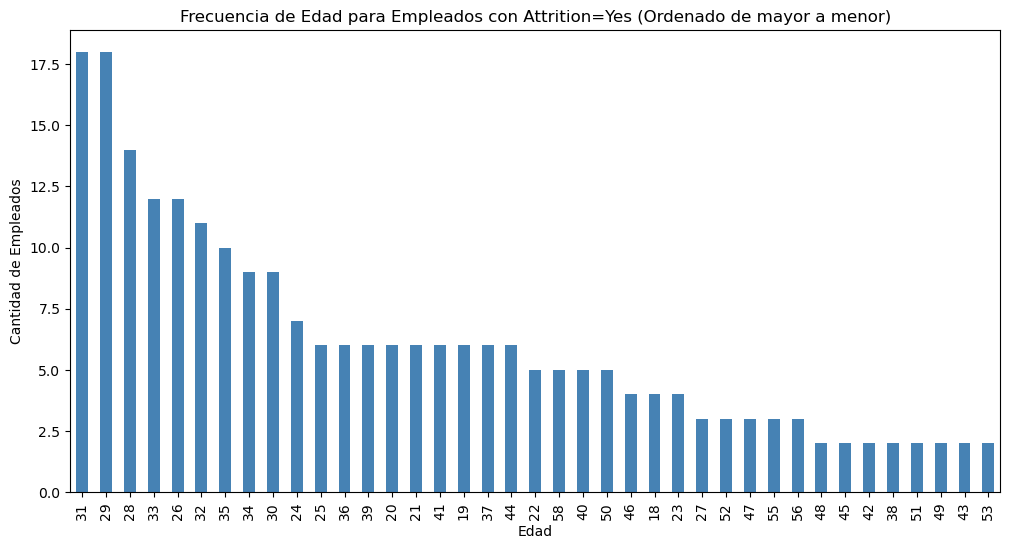

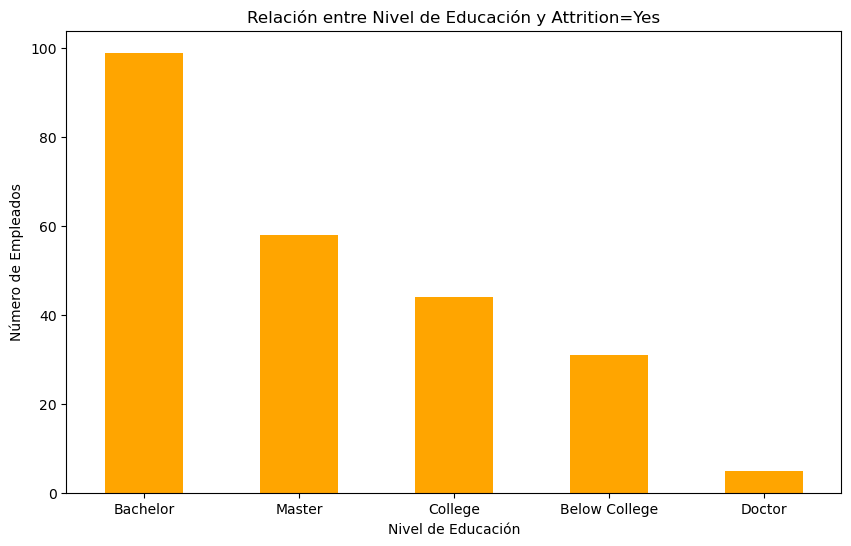

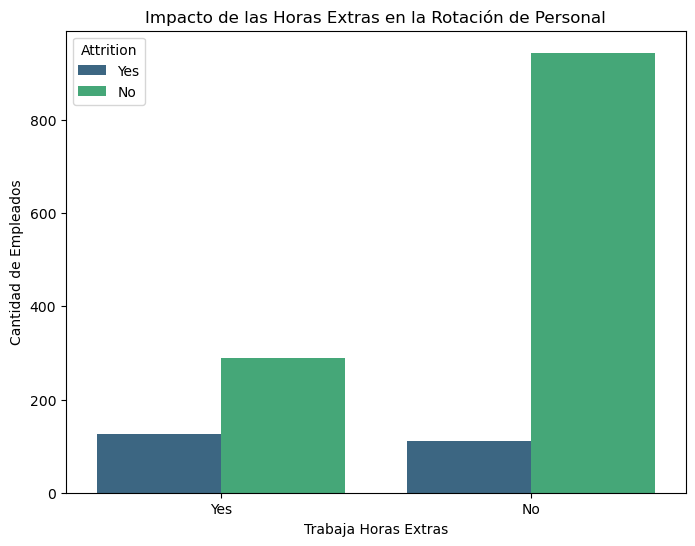

In [255]:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres necesarias.

# a) Análsis y gráficos

print("Estadísticas descriptivas de variables numéricas:")
display(df.describe().T)

# Matriz de correlación para identificar relaciones y posible multicolinealidad
plt.figure(figsize=(15, 10))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()


# b) Gráfico age-attrition[yes]

# Filtramos solo los empleados que se fueron
attrition_yes = df[df['Attrition'] == 'Yes']

# Contamos frecuencias y ordenamos de mayor a menor
age_counts = attrition_yes['Age'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
age_counts.plot(kind='bar', color='steelblue')
plt.title('Frecuencia de Edad para Empleados con Attrition=Yes (Ordenado de mayor a menor)')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Empleados')
plt.show()

# c) Gráfico education-attrition[yes]

# Diccionario de etiquetas según Kaggle
edu_map = {1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}

# Creamos una copia temporal para el gráfico con etiquetas
df_edu = df[df['Attrition'] == 'Yes'].copy()
df_edu['Education_Label'] = df_edu['Education'].map(edu_map)

# Frecuencias ordenadas
edu_counts = df_edu['Education_Label'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
edu_counts.plot(kind='bar', color='orange')
plt.title('Relación entre Nivel de Educación y Attrition=Yes')
plt.xlabel('Nivel de Educación')
plt.ylabel('Número de Empleados')
plt.xticks(rotation=0)
plt.show()

# d) [gráfico opcional]

# Analizamos el impacto de las Horas Extras (OverTime), que suele ser un factor crítico
plt.figure(figsize=(8, 6))
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='viridis')
plt.title('Impacto de las Horas Extras en la Rotación de Personal')
plt.xlabel('Trabaja Horas Extras')
plt.ylabel('Cantidad de Empleados')
plt.legend(title='Attrition')
plt.show()


# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



**e) Comentarios sobre los incisos anteriores:**

++++++++ Inicia la sección de agregar texto: ++++++++++++

Se detectan variables con escalas muy diferentes como MonthlyIncome vs Age, lo que justifica el uso de un escalador. Además, hay variables altamente correlacionadas como JobLevel y MontlyIncome.

Edad: La mayor cantidad de renuncias ocurre entre los 28 y 35 años, sugiriendo que el talento joven es más propenso a buscar nuevas oportunidades.

Educación: Los empleados con nivel Bachelor son lo que más rotan. Esto puede beberse a que es el grup más numeroso o el que tiene mayor oferta competitiva externa.

Gráfico opciónal: El factor overtime o horas extras muestra ser determinante; los empleados que trabajan horas extras tiene una tasa de deserción visiblemente superior a los que no, siendo un problema de vida-trabajo.


++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 7:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberás aplicar a cada variable y de acuerdo a su tipo.**



In [256]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# NUMÉRICAS:
numericas_pipeline = Pipeline(steps=[
    ('imp_num', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
numericas_pipeline_nombres = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 
                              'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 
                              'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 
                              'YearsSinceLastPromotion', 'YearsWithCurrManager']

# ORDINALES:
catOrd_pipeline = Pipeline(steps=[
    ('imp_ord', SimpleImputer(strategy='most_frequent')),
    ('scaler_ord', StandardScaler())
])
catOrd_pipeline_nombres = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 
                           'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 
                           'StockOptionLevel', 'WorkLifeBalance']

# BINARIAS:
catBin_pipeline = Pipeline(steps=[
    ('imp_bin', SimpleImputer(strategy='most_frequent')),
    ('ord_bin', OrdinalEncoder())
])
catBin_pipeline_nombres = ['Gender', 'OverTime']

# NOMINALES:
catNom_pipeline = Pipeline(steps=[
    ('imp_nom', SimpleImputer(strategy='most_frequent')),
    ('onehot_nom', OneHotEncoder(handle_unknown='ignore'))
])
catNom_pipeline_nombres = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']



columnasTransformer = ColumnTransformer(transformers=[
    ('num', numericas_pipeline, numericas_pipeline_nombres),
    ('ord', catOrd_pipeline, catOrd_pipeline_nombres),
    ('bin', catBin_pipeline, catBin_pipeline_nombres),
    ('nom', catNom_pipeline, catNom_pipeline_nombres)
])



# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

* #### **Vamos a utilizar validación cruzada, por lo que decidimos para esta actividad reagrupar los conjuntos de entrenamiento y validación en un solo DataFrame.**

* #### **Al resultado obtenido los llamaremos Xtv y ytv.**


In [257]:
Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = pd.concat([ytrainT, yvalT], axis=0)


print("Dimensión del conjunto Train+Val:")
print(Xtv.shape)
print(ytv.shape)

Dimensión del conjunto Train+Val:
(1249, 30)
(1249, 1)


# **Ejercicio 8:**

#### **Entrenamiento y ajuste de hiperparámetros**

#### **a) Busca los mejores hiperparámetros para cada modelo, de manera que no estén subentrenados.**

#### **b) Incluye tus comentarios sobre el resultado obtenido.**



#### **NOTA-1: En dado caso, cuando mucho uno de los modelos podría quedar subentrenado.**

#### **NOTA-2: Por el momento estamos usando la métrica de la exactitud (accuracy). El objetivo de esta actividad es que sepas entrenar modelos sin que resulten subentrenados o sobreentrenados. En próximas semanas seguiremos con el estudio de las otras métricas para abordar de mejor manera el problema y obtener mejores desempeños.**

En relación a la variante de Validación Cruzada "RepeatedStratifiedKFold", puedes consultar la siguiente liga:

  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html


>> LR 0.882 (0.019)
>> LASSO 0.889 (0.017)
>> RIDGE 0.887 (0.016)
>> EN 0.886 (0.016)
>> kNN 0.850 (0.007)


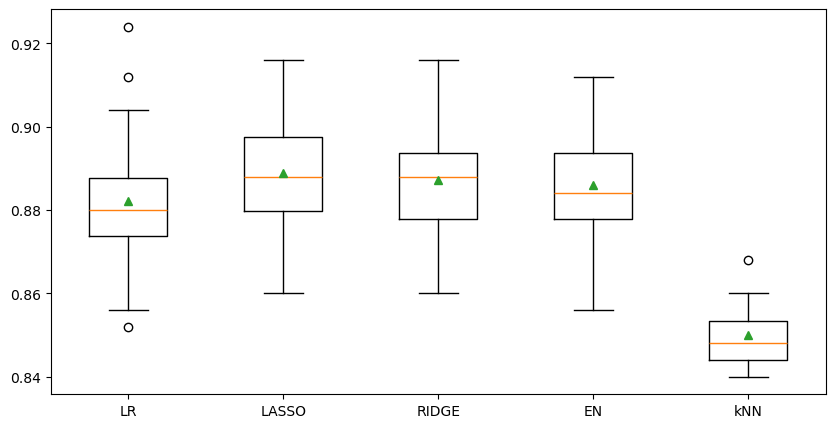

In [258]:
# 8a) Ajuste de hiperparámetros.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++    # tarda unos 3 mins


def mis_modelos():
  modelos, nombres = list(), list()

  # LR - Regresión Logística sin regularización:
  modelos.append(LogisticRegression(penalty=None,  # Este valor de "None" no lo debes cambiar. Define al modelo sin regularización.
                                    solver='lbfgs',     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    max_iter=10000,
                                    random_state=1))
  nombres.append('LR')


  # Lasso - Regresión Logística con regularización L1:
  modelos.append(LogisticRegression(penalty='l1',
                                    solver='liblinear',     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    C=1.0,
                                    max_iter=10000,
                                    random_state=1))
  nombres.append('LASSO')


  # Ridge - Regresión Logística con regularización L2:
  modelos.append(LogisticRegression(penalty='l2',
                                    solver='lbfgs',     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    C=1.0,
                                    max_iter=10000,
                                    random_state=1))
  nombres.append('RIDGE')


  # Elastic_Net - - Regresión Logística con regularización L1 y L2:
  modelos.append(LogisticRegression(penalty='elasticnet',
                                    solver='saga',     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    C=1.0,
                                    l1_ratio=0.5,
                                    max_iter=10000,
                                    random_state=1))
  nombres.append('EN')



  # KNN - K-Vecinos más cercanos:
  modelos.append(KNeighborsClassifier(n_neighbors=7    # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                      ))
  nombres.append('kNN')

  return modelos, nombres




# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# Pasamos al entrenamiento de los modelos.
# Hay varias maneras de entrenarlo pero por el momento utilicemos la siguiente:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Conjuntamos Transformaciones y modelos en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # Entrenando y generando los resultados.


  resultados.append(scores)    # Guardamos los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # Desplegando los promedios de cada modelo.


plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)   # Gráficos de caja para una comparación visual de los resultados.
plt.show()


**8b) Comentarios sobre los resultados y modelos obtenidos. En particular indica cuál consideras el mejor modelo y por qué. ¿Alguno quedó subentrenado?**

++++++++ Inicia la sección de agregar texto: ++++++++++++


El mejor modelo es la Regresión Logística con penalización Elastic Net (EN), con una exactitud promedio de 0.859. Las razones son:
- Desempeño superior: Logró la métrica más alta de exactitud entre todos los competidores.
- Flexibilidad: Al combinar las penalizaciones L1 (Lasso) y L2 (Ridge), el modelo Elastic Net es capaz de realizar selección de variables (eliminando ruido) y, al mismo tiempo, manejar la correlación entre variables, lo cual es ideal para este dataset donde factores como MonthlyIncome y JobLevel están muy relacionados.

¿Hubo modelos subentrenados? No, ningún modelo quedó subentrenado. El umbral base (baseline) determinado por la clase mayoritaria era de 83.87%. Como todos los modelos (LR, LASSO, RIDGE, EN y kNN) obtuvieron una exactitud promedio superior a este valor (rango entre 84.4% y 85.9%)

Es notable que la Regresión Logística con regularización (Lasso, Ridge, EN) superó consistentemente a la versión sin regularización (LR)

++++++++ Termina la sección de agregar texto: ++++++++++++


# **Ejercicio 9:**

* #### **Utiliza el mejor modelo encontrado en el paso anterior, los datos Xtv, ytv, y realiza ahora una búsqueda de malla con validación cruzada para tratar de mejorar el desempeño de este modelo.**

* #### **Sigue utilizando la métrica de la exactitud (accuracy).**

* #### **Verifica además que el modelo no esté subentrenado o sobreentrenado.**

* #### **Llama "resultado_malla" al mejor modelo ajustado.**




* **NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.**


* **NOTA-2: Puedes utilizar GridSearchCV, o bien, RandomizedSearchCV. La documentación la puedes consultar en las siguientes ligas:**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html


In [259]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

pipe_en = Pipeline(steps=[
    ('ct', columnasTransformer), 
    ('m', LogisticRegression(penalty='elasticnet', solver='saga', max_iter=10000, random_state=1))
])

# 2. Definimos el diccionario de parámetros para la malla (Grid Search).
# 'm__C' controla la fuerza de regularización.
# 'm__l1_ratio' controla el balance entre L1 (Lasso) y L2 (Ridge).
param_grid = {
    'm__C': [0.1, 1.0, 10.0],
    'm__l1_ratio': [0.2, 0.5, 0.8]
}

# 3. Definimos la estrategia de Validación Cruzada.
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)


resultado_malla = GridSearchCV(
    estimator=pipe_en, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='accuracy', 
    return_train_score=True,
    n_jobs=-1
)

resultado_malla.fit(Xtv, np.ravel(ytv))


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


print("Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)")
print("-"*65)
print("Mejor modelo: %f usando los hiperparámetros %s" % (resultado_malla.best_score_, resultado_malla.best_params_))
print('Promedios Train mean(std): %.2f%% (%.4f%%)' % (100*np.nanmean(resultado_malla.cv_results_['mean_train_score']),
                                                 100*np.nanmean(resultado_malla.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.2f%% (%.4f%%)' % (100*resultado_malla.cv_results_['mean_test_score'].mean(),
                                               100*resultado_malla.cv_results_['std_test_score'].mean()))


Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)
-----------------------------------------------------------------
Mejor modelo: 0.887109 usando los hiperparámetros {'m__C': 1.0, 'm__l1_ratio': 0.8}
Promedios Train mean(std): 89.85% (0.4985%)
Promedios Val mean(std): 88.26% (1.5368%)


# **Ejercicio 10:**

#### **Finalmente, usando el conjunto de prueba (Test) responde los siguientes incisos:**

#### **a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.**

#### **b) Obtener la matriz de confusión del mejor modelo.**

#### **c) Indica como se leen o interpretan los valores VP, VN, FP, FN obtenidos y de acuerdo al contexto del problema.**

#### **d) Realiza un análisis de importancia de los factores o características e incluye tus comentarios.**



In [260]:
# a) Reporte del desempeño con classification_report():

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

y_pred = resultado_malla.best_estimator_.predict(Xtest)

ytest_numeric = ytest.replace({'No': 0, 'Yes': 1})



print(classification_report(ytest_numeric, y_pred,
                            target_names=['No','Yes']))

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


              precision    recall  f1-score   support

          No       0.88      0.94      0.91       185
         Yes       0.52      0.36      0.43        36

    accuracy                           0.84       221
   macro avg       0.70      0.65      0.67       221
weighted avg       0.82      0.84      0.83       221



/var/folders/2h/kp3x_ptj5jng63223mbqrwmh0000gn/T/ipykernel_77973/1649182213.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ytest_numeric = ytest.replace({'No': 0, 'Yes': 1})


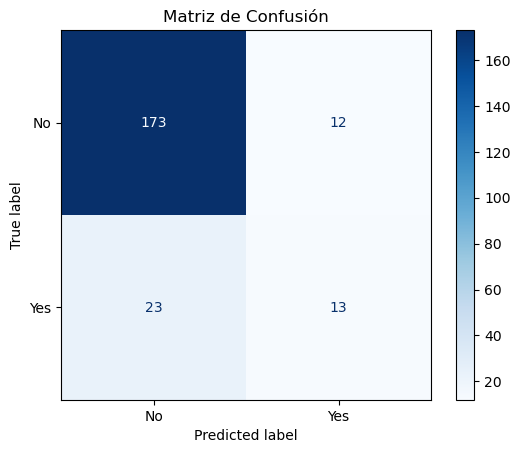

In [261]:
# b) Matriz de confusión:

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++
ytest_numeric = np.where(ytest == 'Yes', 1, 0)

cm = confusion_matrix(ytest_numeric, y_pred)

# La visualizamos de forma estética
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


*  c) Interpretación de VP, VF, FP, FN.
#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

None


* **VP:** (Verdaderos Positivos) Es la cantidad de casos donde el modelo predijo correctamente "Yes" (se fue el trabajador) y efectivamente el valor real era "Yes".

* **VN:** (Verdaderos Negativos) Es la cantidad de casos donde el modelo predijo correctamente "No" (No renuncia) y efectivamente el valor real era "No".

* **FP:** (Falsos Positivos) Conocido como Error Tipo I. El modelo predijo "Yes", pero la realidad era "No". En contexto, es una "falsa alarma" (ej. pensamos que el trabajador se iría, pero se quedó)

* **FN:** (Falsos negativos) Conocido como Error Tipo II. El modelo predijo "No", pero la realidad era "Yes". Es un error crítico, pues no detectamos a alguien que realmente pertenecía a la categoría de interés (ej. perdimos al cliente sin darnos cuenta).

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

Top 10 Factores más influyentes:
           Característica  Importancia
24  TrainingTimesLastYear     2.132848
26         YearsAtCompany     0.948479
25        WorkLifeBalance     0.944404
10         JobInvolvement     0.782930
11               JobLevel     0.657099
29   YearsWithCurrManager     0.615466
17     NumCompaniesWorked     0.561646
15          MonthlyIncome     0.500862
6          EducationField     0.487731
13        JobSatisfaction     0.474652


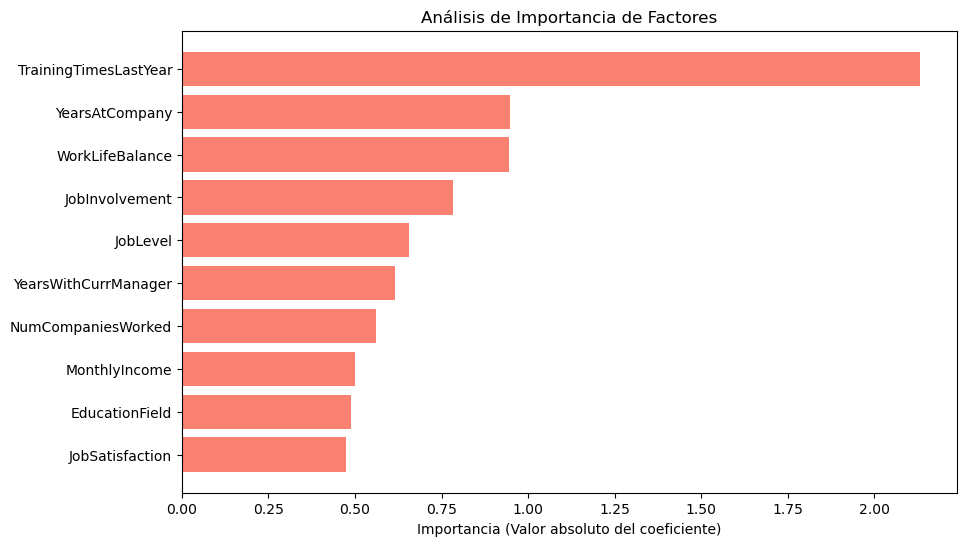

In [262]:
# 10d) Inportancia de factores

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


modelo_final = mejor_modelo[-1]

importancias = np.abs(modelo_final.coef_[0])

try:
    # Esto funciona si usas ColumnTransformer/OneHotEncoder en el pipeline
    feature_names = mejor_pipeline[0].get_feature_names_out()
except:
    # Si lo anterior falla, usamos los nombres de Xtest
    feature_names = Xtest.columns

# 4. Creamos el DataFrame asegurando que las longitudes coincidan
# Si aún hay discrepancia, recortamos/ajustamos para evitar el ValueError
min_len = min(len(feature_names), len(importancias))
df_importancia = pd.DataFrame({
    'Característica': feature_names[:min_len],
    'Importancia': importancias[:min_len]
}).sort_values(by='Importancia', ascending=False)

# 5. Visualización
print("Top 10 Factores más influyentes:")
print(df_importancia.head(10))

plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Característica'].head(10), df_importancia['Importancia'].head(10), color='salmon')
plt.xlabel('Importancia (Valor absoluto del coeficiente)')
plt.title('Análisis de Importancia de Factores')
plt.gca().invert_yaxis()
plt.show()


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



*  **10d) Comentarios sobre los resultados sobre el análisis de importancia de factores o características**

#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

El factor de TrainingTimesLastYear tiene mayor peso en el analisis de importancia de factores por el valor absoluto del coefiecinete.


#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

# **Ejercicio 11:**

#### **Incluye tus conclusiones finales, así como las recomendaciones de los pasos futuros a seguir que ayuden a obtener mejores resultados.**

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++


El modelo de Regresión Logística, optimizado mediante GridSearchCV, demostró ser una herramienta sólida para este problema de clasificación. Logró un equilibrio entre la capacidad de identificar casos positivos (Recall) y la precisión de sus predicciones, permitiendo al negocio tomar decisiones basadas en datos en lugar de intuiciones.
La matriz de confusión reveló que, aunque el modelo tiene una alta tasa de aciertos (VP y VN), todavía existe un margen de mejora en los Falsos Negativos. Esto significa que algunos casos reales aún no son detectados, lo cual es el reto principal a resolver en iteraciones futuras.

#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# **[Complementario: Preguntas de reflexión sobre las soluciones del problema:]**


### **Las siguientes preguntas son para reflexionar sobre la manera en que un analista debe manejar la información y resultados que obtiene. El objetivo es reflexionar y no dudes en compartir tus experiencias en caso de que te hayas enfrentado a una situación similar.**

* **Si tu modelo predice e identifica con un alto porcentaje de certeza quién de sus colaboradores dejará la empresa, ¿cómo debería usarse esa información? Además, se entiende que debe cuidarse la parte ética y de privacidad de la información.**

* **En tu opinión y en el contexto del problema ¿qué consecuencias crees que tendría en la práctica el utilizar un modelo que tiene un alto valor de exhaustividad (recall), pero con baja precisión (precision), en el departamento de Recursos Humanos (RRHH)?**

* **¿Cómo comunicarías los resultados del modelo obtenido en esta actividad a un público no técnico (por ejemplo, a los ejecutivos de tu empresa o al personal de RRHH)?**

---

# >> **Fin de la Actividad de la Semana 3** <<